In [2]:
from collections import defaultdict
import math
import scipy.optimize
import numpy as np
import string
from sklearn.metrics import mean_squared_error as mse
from sklearn import linear_model
from sklearn.linear_model import Ridge
import random
import gzip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
df_raw_recipes = pd.read_csv("archive/RAW_recipes.csv")
df_raw_recipes.head()
df_raw_recipes.columns

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='object')

In [4]:
df_interactions = pd.read_csv("archive/RAW_interactions.csv")
df_interactions.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


In [5]:
df_interactions = df_interactions.sample(frac=1,random_state=15).reset_index(drop=True)
train_size = 0.8
val_size = 0.1
test_size = 0.1

n = len(df_interactions)
n_train = int(n * train_size)
n_val = int(n * val_size)

df_training = df_interactions[:n_train]
df_validation = df_interactions[n_train : n_train + n_val]
df_test = df_interactions[n_train + n_val :]


In [6]:
df_interactions = df_interactions.merge(
    df_raw_recipes[['id', 'name']],   # take recipe id + recipe name
    left_on='recipe_id',
    right_on='id',
    how='left'
)

df_interactions = df_interactions.drop(columns=['id'])
df_interactions.head()

,user_id,recipe_id,date,rating,review,name
0,27783,134725,2010-04-28,4,These were very easy to prepare and tasted ver...,cracker barrel grilled chicken tenders
1,82367,12568,2004-04-20,3,I made with chicken as I do not like shrimp a...,italian chicken or shrimp w tomato cream sauce
2,1240980,88222,2009-04-16,5,"This cake is wonderful, the sugar could be cut...",best sour cream pound cake in the world
3,339773,69630,2008-04-27,5,WOO-HOO!!!!! I finally found a recipe to make...,white almond sour cream wedding cake
4,291235,56645,2006-11-19,5,These cookies are ridiculous. They are SO good...,minnesota s favorite cookies


In [7]:
df_recipes = pd.read_csv("archive/PP_recipes.csv")
df_recipes.head()

,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,..."
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332],...","[40480, 40482, 8240, 481, 24176, 296, 1353, 66...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696..."
3,74301,168258,"[40480, 10025, 31156, 40481]","[[1270, 1645, 28447], [21601], [27952, 29471, ...","[40480, 40482, 5539, 21601, 1073, 903, 2324, 4...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,"[7940, 3609, 7060, 6265, 1170, 6654, 5003, 3561]"
4,76272,109030,"[40480, 17841, 252, 782, 2373, 1641, 2373, 252...","[[1430, 11434], [1430, 17027], [1615, 23, 695,...","[40480, 40482, 14046, 1430, 11434, 488, 17027,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[3484, 6324, 7594, 243]"


In [8]:
df_users = pd.read_csv("archive/PP_users.csv")
df_users.head()

,u,techniques,items,n_items,ratings,n_ratings
0,0,"[8, 0, 0, 5, 6, 0, 0, 1, 0, 9, 1, 0, 0, 0, 1, ...","[1118, 27680, 32541, 137353, 16428, 28815, 658...",31,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, ...",31
1,1,"[11, 0, 0, 2, 12, 0, 0, 0, 0, 14, 5, 0, 0, 0, ...","[122140, 77036, 156817, 76957, 68818, 155600, ...",39,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...",39
2,2,"[13, 0, 0, 7, 5, 0, 1, 2, 1, 11, 0, 1, 0, 0, 1...","[168054, 87218, 35731, 1, 20475, 9039, 124834,...",27,"[3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, ...",27
3,3,"[498, 13, 4, 218, 376, 3, 2, 33, 16, 591, 10, ...","[163193, 156352, 102888, 19914, 169438, 55772,...",1513,"[5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 5.0, 5.0, 5.0, ...",1513
4,4,"[161, 1, 1, 86, 93, 0, 0, 11, 2, 141, 0, 16, 0...","[72857, 38652, 160427, 55772, 119999, 141777, ...",376,"[5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 5.0, 4.0, 5.0, ...",376


In [9]:
df_raw_recipes[['calories','total fat (PDV)','sugar (PDV)','sodium (PDV)','protein (PDV)','saturated fat (PDV)','carbohydrates (PDV)']] = df_raw_recipes.nutrition.str.split(",",expand=True) 
df_raw_recipes['calories'] =  df_raw_recipes['calories'].apply(lambda x: x.replace('[','')) 
df_raw_recipes['carbohydrates (PDV)'] =  df_raw_recipes['carbohydrates (PDV)'].apply(lambda x: x.replace(']','')) 
df_raw_recipes[['calories','total fat (PDV)','sugar (PDV)','sodium (PDV)','protein (PDV)','saturated fat (PDV)','carbohydrates (PDV)']] = df_raw_recipes[['calories','total fat (PDV)','sugar (PDV)','sodium (PDV)','protein (PDV)','saturated fat (PDV)','carbohydrates (PDV)']].astype('float')
df_raw_recipes.dtypes


name                    object
id                       int64
minutes                  int64
contributor_id           int64
submitted               object
tags                    object
nutrition               object
n_steps                  int64
steps                   object
description             object
ingredients             object
n_ingredients            int64
calories               float64
total fat (PDV)        float64
sugar (PDV)            float64
sodium (PDV)           float64
protein (PDV)          float64
saturated fat (PDV)    float64
carbohydrates (PDV)    float64
dtype: object

In [10]:
df_raw_recipes.drop(['contributor_id','submitted','tags','nutrition','steps','description'], axis=1,inplace = True)
df_raw_recipes.head()


,name,id,minutes,n_steps,ingredients,n_ingredients,calories,total fat (PDV),sugar (PDV),sodium (PDV),protein (PDV),saturated fat (PDV),carbohydrates (PDV)
0,arriba baked winter squash mexican style,137739,55,11,"['winter squash', 'mexican seasoning', 'mixed ...",7,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,a bit different breakfast pizza,31490,30,9,"['prepared pizza crust', 'sausage patty', 'egg...",6,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,all in the kitchen chili,112140,130,6,"['ground beef', 'yellow onions', 'diced tomato...",13,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,alouette potatoes,59389,45,11,"['spreadable cheese with garlic and herbs', 'n...",11,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,amish tomato ketchup for canning,44061,190,5,"['tomato juice', 'apple cider vinegar', 'sugar...",8,352.9,1.0,337.0,23.0,3.0,0.0,28.0


/var/folders/gc/w6t6ktt94hg5ckfj2nytpt0m0000gn/T/ipykernel_24895/3098862148.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")


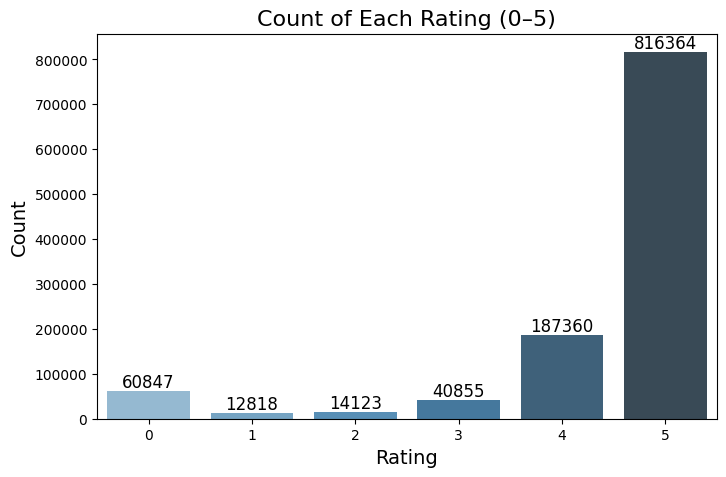

In [11]:
#Rating Distribution Plot

# Count ratings explicitly in order 0–5
rating_counts = df_interactions['rating'].value_counts().reindex([0,1,2,3,4,5], fill_value=0)

plt.figure(figsize=(8,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")

plt.title('Count of Each Rating (0–5)', fontsize=16)
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0,1,2,3,4,5])

# Add values on top of bars
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 0.01*max(rating_counts.values), str(v), ha='center', fontsize=12)

plt.show()




This shows us that the ratings are heavily skewed towards higher ratings

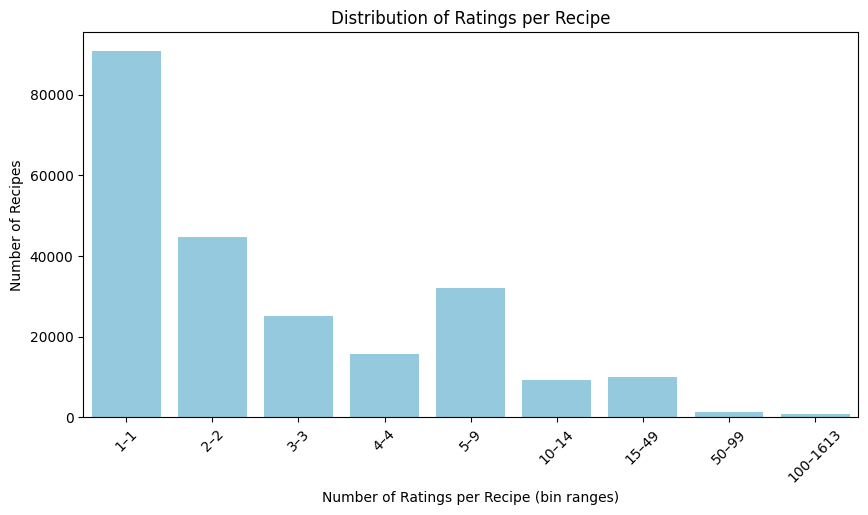

In [12]:
# Count number of ratings per recipe
ratings_per_recipe = df_interactions.groupby('name')['rating'].count()

# Define custom bins (adjust as needed)
bin_edges = [1,2,3,4,5,10, 15, 50, 100, ratings_per_recipe.max()]

# Compute histogram manually
counts, edges = np.histogram(ratings_per_recipe, bins=bin_edges)

# Create readable labels
bin_labels = [f'{edges[i]}–{edges[i+1]-1}' for i in range(len(edges)-1)]

plt.figure(figsize=(10,5))
sns.barplot(x=bin_labels, y=counts, color='skyblue')
plt.xlabel("Number of Ratings per Recipe (bin ranges)")
plt.ylabel("Number of Recipes")
plt.title("Distribution of Ratings per Recipe")
plt.xticks(rotation=45)
plt.show()

/var/folders/gc/w6t6ktt94hg5ckfj2nytpt0m0000gn/T/ipykernel_24895/1487316617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.index.astype(str), y=top20.values, palette='viridis')


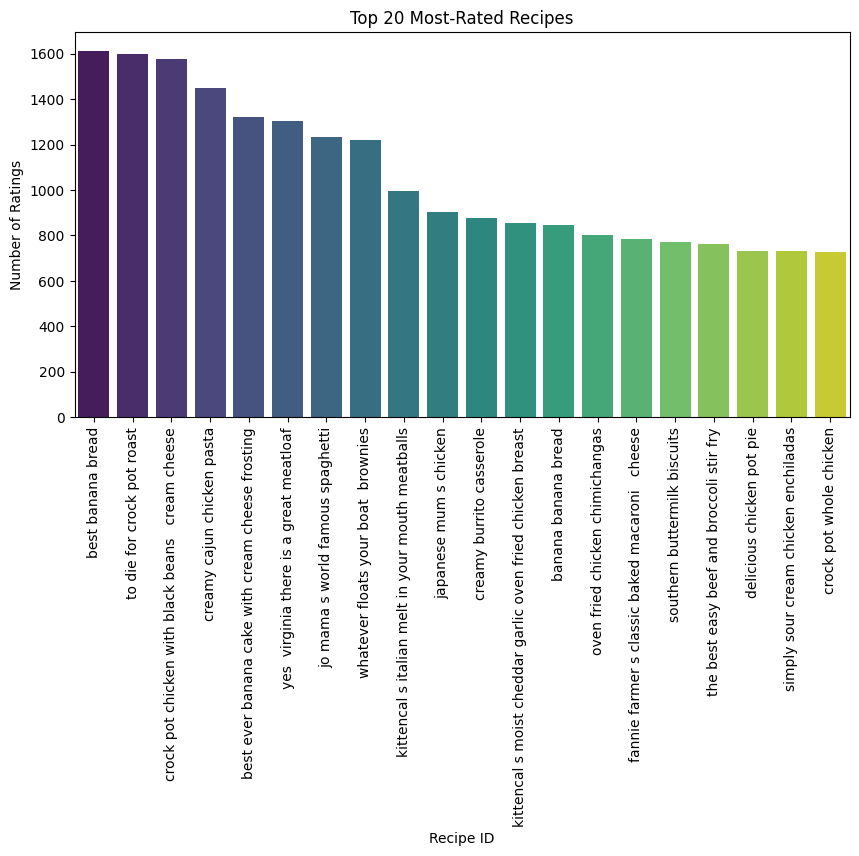

In [13]:
top20 = ratings_per_recipe.nlargest(20)

plt.figure(figsize=(10,5))
sns.barplot(x=top20.index.astype(str), y=top20.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 20 Most-Rated Recipes')
plt.xlabel('Recipe ID')
plt.ylabel('Number of Ratings')
plt.show()


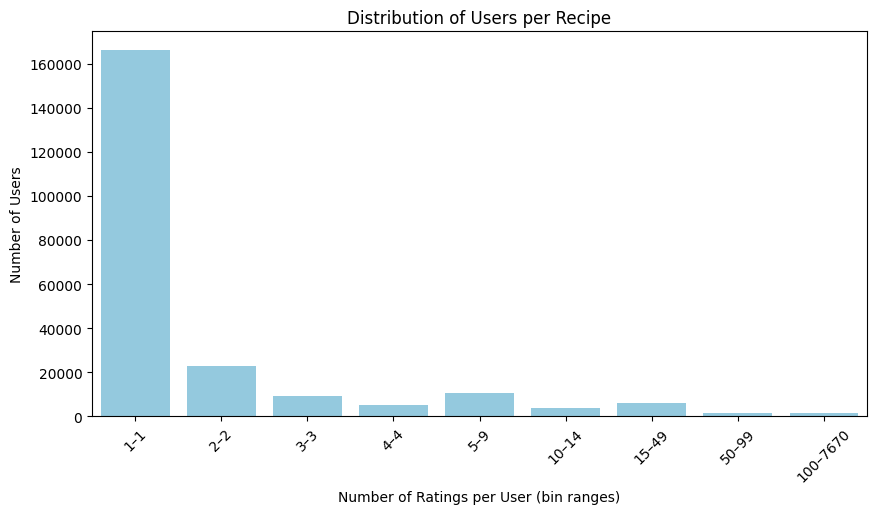

In [14]:
# Count number of ratings per user
ratings_per_user = df_interactions.groupby('user_id')['rating'].count()

# Define custom bins (adjust as needed)
bin_edges = [1,2,3,4,5,10, 15, 50, 100, ratings_per_user.max()]

# Compute histogram manually
counts, edges = np.histogram(ratings_per_user, bins=bin_edges)

# Create readable labels
bin_labels = [f'{edges[i]}–{edges[i+1]-1}' for i in range(len(edges)-1)]

plt.figure(figsize=(10,5))
sns.barplot(x=bin_labels, y=counts, color='skyblue')
plt.xlabel("Number of Ratings per User (bin ranges)")
plt.ylabel("Number of Users")
plt.title("Distribution of Users per Recipe")
plt.xticks(rotation=45)
plt.show()


/var/folders/gc/w6t6ktt94hg5ckfj2nytpt0m0000gn/T/ipykernel_24895/936190141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_users.index.astype(str), y=top20_users.values, palette='viridis')


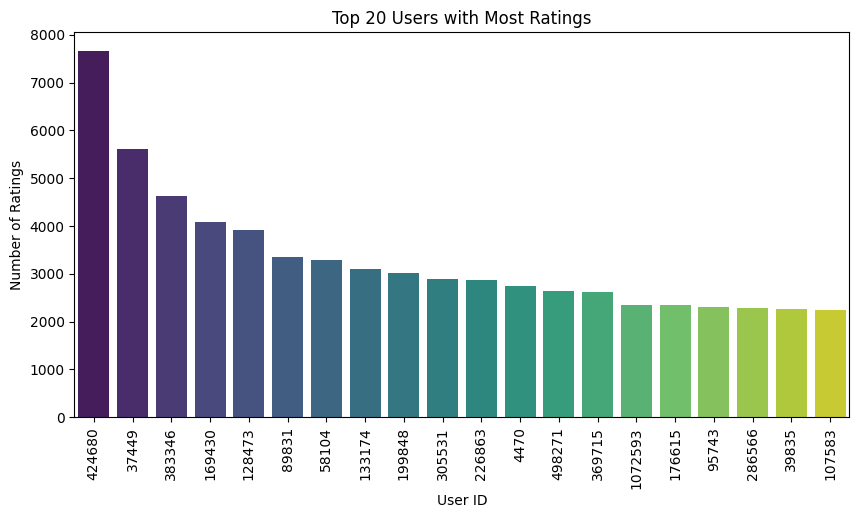

In [15]:
top20_users = ratings_per_user.nlargest(20)

plt.figure(figsize=(10,5))
sns.barplot(x=top20_users.index.astype(str), y=top20_users.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 20 Users with Most Ratings')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.show()

<Axes: xlabel='num_ratings', ylabel='avg_rating'>

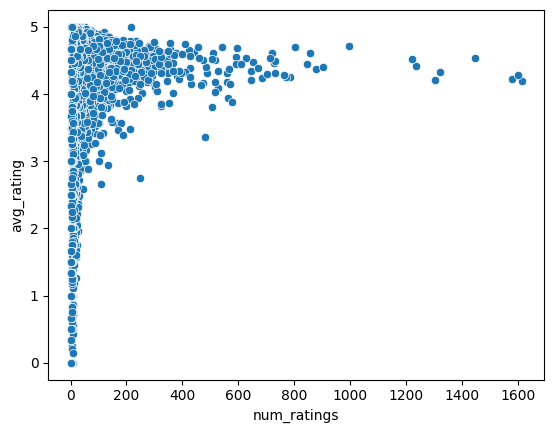

In [16]:
recipe_stats = df_interactions.groupby('name').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
)

sns.scatterplot(data=recipe_stats, x='num_ratings', y='avg_rating')


<Axes: xlabel='n_ingredients', ylabel='Count'>

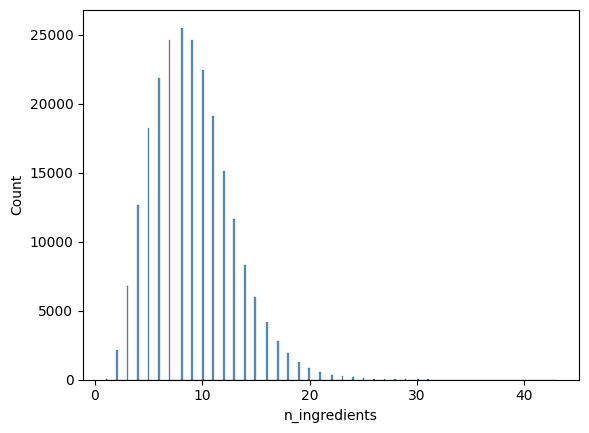

In [17]:
sns.histplot(df_raw_recipes['n_ingredients'])

<Axes: xlabel='n_steps', ylabel='Count'>

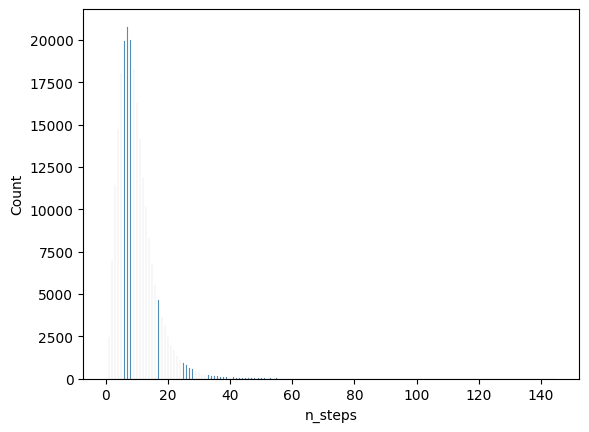

In [18]:
sns.histplot(df_raw_recipes['n_steps'])


WE WILL NOW BEGIN MODELING

In [ ]:
### Basline Model 1: Predicted Rating is the Mean for that recipe based on the training data. If the recipe doesn't have
###    any reviews, predict the mean of the training data.

In [19]:
# Mean rating for each recipe from training data only
recipe_means = df_training.groupby('recipe_id')['rating'].mean()

global_mean = df_training['rating'].mean()
global_mean


4.411254971613645

In [20]:
def baseline_predict_rating(recipe_id):
    # Use recipe mean if available, else fallback to global mean
    return recipe_means.get(recipe_id, global_mean)

In [21]:
df_validation['pred'] = df_validation['recipe_id'].apply(baseline_predict_rating)

rmse_val = mse(df_validation['rating'], df_validation['pred'], squared=False)
rmse_val

1.3431404077804983

In [22]:
df_test['pred'] = df_test['recipe_id'].apply(baseline_predict_rating)

rmse_test = mse(df_test['rating'], df_test['pred'], squared=False)
rmse_test

1.3327536080747902

In [23]:
### Item Based Collaborative Fitting Model

In [24]:
ratingsPerUser = defaultdict(list)
ratingsPerItem = defaultdict(list)

for _, row in df_training.iterrows():
    u = row['user_id']
    i = row['recipe_id']
    r = row['rating']
    
    ratingsPerUser[u].append((i, r))
    ratingsPerItem[i].append((u, r))

In [25]:
def pearson_similarity(i, j):
    # ratingsPerItem[i] = [(user, rating), ...]
    users_i = {u:r for u,r in ratingsPerItem[i]}
    users_j = {u:r for u,r in ratingsPerItem[j]}
    
    # Users who rated both items
    common = users_i.keys() & users_j.keys()
    if len(common) == 0:
        return 0.0

    # Extract aligned rating lists
    ratings_i = [users_i[u] for u in common]
    ratings_j = [users_j[u] for u in common]

    mean_i = sum(ratings_i) / len(ratings_i)
    mean_j = sum(ratings_j) / len(ratings_j)

    # Mean-centered ratings
    diff_i = [r - mean_i for r in ratings_i]
    diff_j = [r - mean_j for r in ratings_j]

    num = sum(di * dj for di, dj in zip(diff_i, diff_j))
    den_i = math.sqrt(sum(di * di for di in diff_i))
    den_j = math.sqrt(sum(dj * dj for dj in diff_j))

    denom = den_i * den_j
    if denom == 0:
        return 0.0

    return num / denom


In [26]:
def predict_item_cf(u, i, k=20):
    rated_items = ratingsPerUser[u]

    sims = []
    for j, r_j in rated_items:
        if j == i:
            continue
        sim = pearson_similarity(i, j)
        if sim > 0:                  # use positive correlations only
            sims.append((sim, r_j))

    if not sims:
        return recipe_means.get(i, global_mean)

    # sort by similarity
    sims = sorted(sims, key=lambda x: x[0], reverse=True)[:k]

    num = sum(sim * r for sim, r in sims)
    den = sum(sim for sim, _ in sims)

    if den == 0:
        return recipe_means.get(i, global_mean)

    return num / den


In [27]:
preds = []
for _, row in df_validation.iterrows():
    u = row['user_id']
    i = row['recipe_id']
    true = row['rating']
    
    if u not in ratingsPerUser:
        preds.append(global_mean)
    else:
        preds.append(predict_item_cf(u, i))


In [28]:
rmse_val = mse(df_validation['rating'], preds, squared=False)
rmse_val


1.36217387720756

In [29]:
train_recipes = set(df_training['recipe_id'])
val_recipes   = set(df_validation['recipe_id'])
test_recipes  = set(df_test['recipe_id'])

print("Train ∩ Val:", len(train_recipes & val_recipes))
print("Train ∩ Test:", len(train_recipes & test_recipes))
print("Val ∩ Test:", len(val_recipes & test_recipes))



Train ∩ Val: 52568
Train ∩ Test: 52541
Val ∩ Test: 25539


Item Based CF Model does not outperform the baseline. Should not use CF model because many recipes only have one review

In [ ]:
### Simple Regression Model using Minutes, #ingredient, #steps

In [ ]:
recipe_features = df_raw_recipes[['id', 'minutes', 'n_steps', 'n_ingredients']].copy()

### Fill missing or weird values
recipe_features['minutes'] = recipe_features['minutes'].fillna(recipe_features['minutes'].median())
recipe_features['n_steps'] = recipe_features['n_steps'].fillna(0)
recipe_features['n_ingredients'] = recipe_features['n_ingredients'].fillna(0)

recipe_features.head()


,id,minutes,n_steps,n_ingredients
0,137739,55,11,7
1,31490,30,9,6
2,112140,130,6,13
3,59389,45,11,11
4,44061,190,5,8


In [31]:
train = df_training.merge(recipe_features, left_on='recipe_id', right_on='id', how='left')
val   = df_validation.merge(recipe_features, left_on='recipe_id', right_on='id', how='left')
test  = df_test.merge(recipe_features, left_on='recipe_id', right_on='id', how='left')


In [32]:
feature_cols = ['minutes', 'n_steps', 'n_ingredients']

X_train = train[feature_cols]
y_train = train['rating']

X_val = val[feature_cols]
y_val = val['rating']


In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred_val = model.predict(X_val)
rmse_val = mse(y_val, pred_val, squared=False)
rmse_val

1.268990154126192

Regression using minutes, n_steps, and n_ingredients outperforms the baseline

In [ ]:
### TF-IDF Model, using Ingredients to predict Ratings

In [34]:
df_raw_recipes['ingredients'].iloc[0]


"['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter', 'olive oil', 'salt']"

In [35]:
import ast

df_raw_recipes['ingredients_list'] = df_raw_recipes['ingredients'].apply(ast.literal_eval)
df_raw_recipes['ingredients_str'] = df_raw_recipes['ingredients_list'].apply(lambda lst: " ".join(lst))

tfidf = TfidfVectorizer(
    min_df=5,        # ignore extremely rare ingredients
    max_df=0.9,      # ignore extremely common ingredients
    stop_words=None  # ingredients are not English sentences
)

X_ing = tfidf.fit_transform(df_raw_recipes['ingredients_str'])
recipe_to_idx = {rid: idx for idx, rid in enumerate(df_raw_recipes['id'])}

def get_tfidf_row(recipe_id):
    idx = recipe_to_idx.get(recipe_id, None)
    if idx is None:
        # if recipe not found — rare — return zero vector
        return np.zeros(X_ing.shape[1])
    return X_ing[idx].toarray().squeeze()


In [36]:
train_indices = [recipe_to_idx[r] for r in df_training['recipe_id']]
val_indices   = [recipe_to_idx[r] for r in df_validation['recipe_id']]
test_indices  = [recipe_to_idx[r] for r in df_test['recipe_id']]

X_train = X_ing[train_indices]  # still sparse!
X_val   = X_ing[val_indices]    # still sparse!
X_test  = X_ing[test_indices]   # still sparse!

y_train = df_training['rating'].values
y_val   = df_validation['rating'].values
y_test  = df_test['rating'].values


In [37]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

Ridge()

In [38]:
pred_val = model.predict(X_val)
rmse_val = mse(y_val, pred_val, squared=False)
rmse_val

1.2634582591063606

TF-IDF Model using Ingredients to predict Rating is best model so far.

In [ ]:
### Next will do Personalized TF-IDF user model

In [53]:
ratingsTrain = df_training[['user_id', 'recipe_id', 'rating']].values.tolist()
ratingsValid = df_validation[['user_id', 'recipe_id', 'rating']].values.tolist()


ratingsPerUser = defaultdict(list)
ratingsPerItem = defaultdict(list)

for _, row in df_training.iterrows():
    u = row['user_id']
    r = row['rating']
    rid = row['recipe_id']
    ratingsPerUser[u].append((rid, r))
    ratingsPerItem[rid].append((u,r))

In [40]:
def get_item_vec(recipe_id):
    idx = recipe_to_idx.get(recipe_id)
    if idx is None:
        return None
    return X_ing[idx]   # sparse 1×D row vector


In [41]:
user_profiles = {}
user_ratings = defaultdict(list)

# Collect user's (recipe, rating) pairs from TRAINING set
for _, row in df_training.iterrows():
    u  = row['user_id']
    r  = row['rating']
    rid = row['recipe_id']
    user_ratings[u].append((rid, r))

# Build normalized sparse user profiles
for u, items in user_ratings.items():
    vecs = []
    weights = []
    
    for rid, rating in items:
        item_vec = get_item_vec(rid)
        if item_vec is not None:
            vecs.append(item_vec)
            weights.append(rating)  # can also center: rating - global_mean
    
    if len(vecs) == 0:
        continue
    
    # Stack sparse item vectors
    M = sp.vstack(vecs)            # (num_items × D)
    w = np.array(weights)          # (num_items,)
    
    # Weighted sum → sparse vector
    user_vec = w @ M               # shape (1 × D) dense? No → sparse only if M is CSR
    
    # Convert to sparse row vector
    user_vec = sp.csr_matrix(user_vec)
    
    # Normalize to unit length
    norm = np.sqrt(user_vec.multiply(user_vec).sum())
    if norm > 0:
        user_vec = user_vec / norm
    
    user_profiles[u] = user_vec

In [42]:
def predict_user_profile(u, rid):
    # Fallback for cold-start user or recipe
    if u not in user_profiles:
        return global_mean
    
    item_vec = get_item_vec(rid)
    if item_vec is None:
        return global_mean
    
    user_vec = user_profiles[u]
    
    sim = cosine_similarity(user_vec, item_vec)[0][0]
    
    # Map similarity to rating
    pred = 1 + 4 * sim
    
    # Optional: clamp to rating range
    pred = min(5, max(1, pred))
    return pred

In [43]:
preds = []
true = df_validation['rating'].values

for _, row in df_validation.iterrows():
    u = row['user_id']
    rid = row['recipe_id']
    preds.append(predict_user_profile(u, rid))

rmse_val = mse(true, preds, squared=False)
rmse_val




2.7597579770542313

Performs very poorly because many users only have 1 review so it is hard to personalize

In [ ]:
### Latent Factor Model

In [45]:
def alphaUpdate(ratingsTrain, alpha, betaU, betaI, lamb):
    # Update equation for alpha
    total = 0.0
    for u,b,r in ratingsTrain:
        total += (r - betaU[u] - betaI[b])
    newAlpha = total / len(ratingsTrain)
    return newAlpha

In [46]:
def betaUUpdate(ratingsPerUser, alpha, betaU, betaI, lamb):
    # Update equation for betaU
    newBetaU = {}
    for u,ratings in ratingsPerUser.items():
        numer = 0.0
        for b,r in ratings:
            numer += (r - alpha - betaI[b])
        denom = lamb + len(ratings)
        newBetaU[u] = numer / denom
    return newBetaU

In [47]:
def betaIUpdate(ratingsPerItem, alpha, betaU, betaI, lamb):
    # Update equation for betaI
    newBetaI = {}
    for b,ratings in ratingsPerItem.items():
        numer = 0.0
        for u,r in ratings:
            numer += (r - alpha - betaU[u])
        denom = lamb + len(ratings)
        newBetaI[b] = numer / denom

    return newBetaI

In [48]:
def validMSE(ratingsValid, alpha, betaU, betaI, P, Q):
    mse = 0.0
    for u, i, r in ratingsValid:
        bu = betaU.get(u, 0.0)
        bi = betaI.get(i, 0.0)
        pu = P.get(u, None)
        qi = Q.get(i, None)

        mf_term = np.dot(pu, qi) if (pu is not None and qi is not None) else 0.0
        pred = alpha + bu + bi + mf_term

        mse += (pred - r) ** 2

    return mse / len(ratingsValid)

In [56]:
def goodModel(
    ratingsTrain,
    ratingsValid, 
    ratingsPerUser, 
    ratingsPerItem,
    alpha, 
    betaU, 
    betaI,
    k = 1,            # latent dimension
    lamb = 0.05,       # regularization strength
    epochs = 30,       # max training epochs
    lr = 0.005          # learning rate
):

    # Convert training list once
    data = list(ratingsTrain)

    # Initialize latent factors
    users = list(ratingsPerUser.keys())
    items = list(ratingsPerItem.keys())

    P = {u: np.random.normal(0, 0.05, k) for u in users}
    Q = {i: np.random.normal(0, 0.05, k) for i in items}

    # Learning rate splits
    lr_bias = lr
    lr_latent = lr

    best_val = float('inf')
    best_model = None
    wait = 0
    patience = 2

    for ep in range(epochs):
        random.shuffle(data)

        # SGD updates
        for u, i, r in data:
            bu = betaU[u]
            bi = betaI[i]
            pu = P[u]
            qi = Q[i]

            # Prediction
            pred = alpha + bu + bi + np.dot(pu, qi)
            err = r - pred

            # Update biases
            betaU[u] += lr_bias * (err - lamb * bu)
            betaI[i] += lr_bias * (err - lamb * bi)

            # Update latent factors
            P[u] += lr_latent * (err * qi - lamb * pu)
            Q[i] += lr_latent * (err * pu - lamb * qi)

        # Update alpha once per epoch
        sum_err = 0.0
        for u, i, r in data:
            sum_err += r - (alpha + betaU[u] + betaI[i] + np.dot(P[u], Q[i]))
        alpha += lr_bias * (sum_err / len(data))

        # Compute training loss for this epoch
        loss = 0.0
        for u, i, r in data:
            pred = alpha + betaU[u] + betaI[i] + np.dot(P[u], Q[i])
            loss += (r - pred) ** 2
        loss /= len(data)

        print(f"Epoch {ep+1:2d} | Training Loss = {loss:.6f}")

        val_mse = validMSE(ratingsValid, alpha, betaU, betaI, P, Q)
        print(f"Epoch {ep+1} | val MSE = {val_mse:.5f}")

        if val_mse < best_val:
            best_val = val_mse
            wait = 0
            # save the current best model
            best_model = (
                alpha,
                betaU.copy(),
                betaI.copy(),
                {u: P[u].copy() for u in P},
                {i: Q[i].copy() for i in Q}
            )
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

        
    return best_model

In [68]:
def tune_model():
    learning_rates = [0.01]
    ks = [5, 10, 15]
    lambdas = [0.01, 0.02, 0.05]

    best_mse = float('inf')
    best_params = None

    for lr in learning_rates:
        for k in ks:
            for lamb in lambdas:
                print(f"\n--- Trying lr={lr}, k={k}, lamb={lamb} ---")

                # init params
                betaU = {u: 0.0 for u in ratingsPerUser}
                betaI = {i: 0.0 for i in ratingsPerItem}
                alpha = global_mean

                # train model
                alpha_, bu_, bi_, P_, Q_ = goodModel(
                    ratingsTrain,
                    ratingsValid,
                    ratingsPerUser,
                    ratingsPerItem,
                    alpha,
                    betaU,
                    betaI,
                    k=k,
                    lamb=lamb,
                    lr=lr,
                    epochs=10
                )

                # compute validation MSE
                mse = validMSE(ratingsValid, alpha_, bu_, bi_, P_, Q_)
                print(f"Val MSE: {mse:.5f}")

                if mse < best_mse:
                    best_mse = mse
                    best_params = (lr, k, lamb)

    print("\nBest Model:")
    print("lr =", best_params[0])
    print("k =", best_params[1])
    print("lambda =", best_params[2])
    print("best validation MSE:", best_mse)


In [51]:
def test_latent():
    betaU = {}
    betaI = {}
    for u in ratingsPerUser:
        betaU[u] = 0

    for b in ratingsPerItem:
        betaI[b] = 0

    alpha = global_mean # Could initialize anywhere, this is a guess
    
    alpha, betaU, betaI, P, Q = goodModel(
        ratingsTrain, 
        ratingsValid,
        ratingsPerUser, 
        ratingsPerItem,
        alpha, 
        betaU, 
        betaI
    )
    validMSE = validMSE(
        ratingsValid, 
        alpha, 
        betaU, 
        betaI, 
        P, 
        Q
    )

    
    print("validMSE = " + str(validMSE))

In [69]:
tune_model()


--- Trying lr=0.01, k=5, lamb=0.01 ---
Epoch  1 | Training Loss = 1.456023
Epoch 1 | val MSE = 1.51873
Epoch  2 | Training Loss = 1.397615
Epoch 2 | val MSE = 1.50279
Epoch  3 | Training Loss = 1.351049
Epoch 3 | val MSE = 1.49407
Epoch  4 | Training Loss = 1.311415
Epoch 4 | val MSE = 1.48936
Epoch  5 | Training Loss = 1.275004
Epoch 5 | val MSE = 1.48592
Epoch  6 | Training Loss = 1.240762
Epoch 6 | val MSE = 1.48350
Epoch  7 | Training Loss = 1.207700
Epoch 7 | val MSE = 1.48231
Epoch  8 | Training Loss = 1.175858
Epoch 8 | val MSE = 1.48201
Epoch  9 | Training Loss = 1.144228
Epoch 9 | val MSE = 1.48228
Epoch 10 | Training Loss = 1.112910
Epoch 10 | val MSE = 1.48306
Early stopping triggered.
Val MSE: 1.48201

--- Trying lr=0.01, k=5, lamb=0.02 ---
Epoch  1 | Training Loss = 1.456355
Epoch 1 | val MSE = 1.51891
Epoch  2 | Training Loss = 1.397981
Epoch 2 | val MSE = 1.50290
Epoch  3 | Training Loss = 1.351792
Epoch 3 | val MSE = 1.49433
Epoch  4 | Training Loss = 1.312058
Epoch 4 

In [57]:
test_latent()

Epoch  1 | Training Loss = 1.496514
Epoch 1 | val MSE = 1.53443
Epoch  2 | Training Loss = 1.456864
Epoch 2 | val MSE = 1.51854
Epoch  3 | Training Loss = 1.425948
Epoch 3 | val MSE = 1.50902
Epoch  4 | Training Loss = 1.399275
Epoch 4 | val MSE = 1.50270
Epoch  5 | Training Loss = 1.375630
Epoch 5 | val MSE = 1.49763
Epoch  6 | Training Loss = 1.353943
Epoch 6 | val MSE = 1.49395
Epoch  7 | Training Loss = 1.333967
Epoch 7 | val MSE = 1.49097


KeyboardInterrupt: 